<a href="https://colab.research.google.com/github/vedantjoshi24-alt/Deep_Learning/blob/main/Assignment_06/DL_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to:
/kaggle/input/plantdisease
['PlantVillage', 'plantvillage']
Found 33022 images belonging to 2 classes.
Found 8254 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 389s 371ms/step - accuracy: 0.5012 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 226s 219ms/step - accuracy: 0.4969 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 223s 216ms/step - accuracy: 0.4964 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 224s 217ms/step - accuracy: 0.5020 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 225s 218ms/step - accuracy: 0.4982 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 221s 214ms/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 220s 213ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 226s 219ms/step - ac

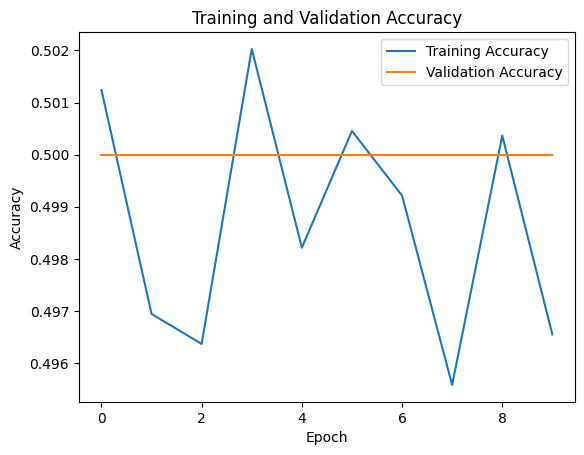

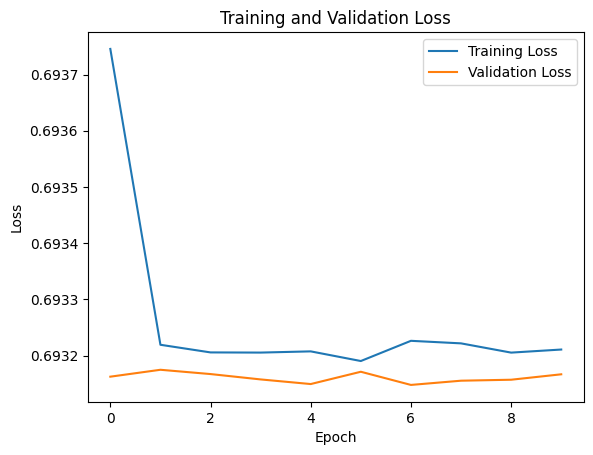


Classes:
0 : PlantVillage
1 : plantvillage
Model saved successfully!


In [ ]:
import tensorflow as tf
import kagglehub
import os
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout


# 1. Download dataset using KaggleHub

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded to:")
print(path)


# 2. Check dataset contents

print(os.listdir(path))


# 3. Set image size

IMG_SIZE = 128
BATCH_SIZE = 32


# 4. Image preprocessing and augmentation

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


# 5. Load training images

train_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)


# 6. Load validation images

validation_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


# 7. Build CNN

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(128, 128, 3)
    ),

    MaxPooling2D((2, 2)),


    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        train_data.num_classes,
        activation='softmax'
    )
])


# 8. Compile model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# 9. Display model architecture

model.summary()


# 10. Train model

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)


# 11. Evaluate model

loss, accuracy = model.evaluate(validation_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)


# 12. Plot accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()


# 13. Plot loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()


# 14. Display classes

print("\nClasses:")

for class_name, class_index in train_data.class_indices.items():
    print(class_index, ":", class_name)


# 15. Save model

model.save("tomato_disease_cnn.h5")

print("Model saved successfully!")